<a href="https://colab.research.google.com/github/ambreenraheem/Machine-Learning-NED/blob/main/data_science_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ambreen Abdul Raheem**
### **The Data Analyst & Web App Developer**
#### **Complete Project Of Data Science**
Date: 01- April- 2026


### **Loading the `car_crashes` Dataset**

The `car_crashes` dataset from Seaborn contains information about fatal motor vehicle crashes in the U.S. in 2012. It includes variables such as total number of crashes, speed-related fatalities, alcohol-related fatalities, etc., per billion miles driven in each state.

In [5]:
import seaborn as sns
import pandas as pd

# Load the car_crashes dataset
car_crashes = sns.load_dataset('car_crashes')

# Display the first 5 rows of the dataset
print("First 5 rows of the car_crashes dataset:")
display(car_crashes.head(5))

print("\nDataset Information:")
car_crashes.info()


First 5 rows of the car_crashes dataset:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     object 
dtypes: float64(7), object(1)
memory usage: 3.3+ KB


## **1. Descriptive Analysis**

Descriptive analysis involves summarizing the main features of a dataset. It helps us understand the basic characteristics of the data, such as its central tendency, dispersion, and shape. We'll look at:

*   Basic statistics (mean, median, min, max, standard deviation)
*   Data types and non-null counts
*   Missing values

In [6]:
print("Descriptive Statistics for car_crashes dataset:")
display(car_crashes.describe())

print("\nMissing Values per column:")
display(car_crashes.isnull().sum())

Descriptive Statistics for car_crashes dataset:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000



Missing Values per column:


,0
total,0
speeding,0
alcohol,0
not_distracted,0
no_previous,0
ins_premium,0
ins_losses,0
abbrev,0


### **Interpretation of Descriptive Analysis:**

*   **`car_crashes.head()`**: Shows the first few rows, giving us a glimpse of the data structure and column names (e.g., `total`, `speeding`, `alcohol`, `not_distracted`, `no_previous`, `ins_premium`, `ins_losses`, `abbrev`). Each row represents a state.
*   **`car_crashes.info()`**: Provides a summary of the DataFrame, including the number of entries (51 states), columns, non-null values, and data types. We can see all numerical columns are `float64` and `abbrev` is `object` (string). There are no missing values in this dataset, as indicated by '51 non-null' for all columns.
*   **`car_crashes.describe()`**: Generates descriptive statistics for numerical columns:
    *   **`count`**: Number of non-null observations (51 for all, confirming no missing values).
    *   **`mean`**: The average value for each column (e.g., average total crashes per billion miles is around 15.79).
    *   **`std`**: The standard deviation, which measures the spread of the data (e.g., total crashes vary by about 4.12 from the mean).
    *   **`min`**: The smallest value observed.
    *   **`25% (Q1)`**: The first quartile (25th percentile).
    *   **`50% (median)`**: The median or second quartile (50th percentile).
    *   **`75% (Q3)`**: The third quartile (75th percentile).
    *   **`max`**: The largest value observed.
*   **`car_crashes.isnull().sum()`**: Confirms that there are no missing values across any of the columns in the dataset.

## **2. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis helps us to understand the data's structure, identify patterns, detect outliers, and test hypotheses. We will use various visualizations and statistical methods to explore the relationships between variables.

### **2.1. Distribution of Numerical Features**

Let's visualize the distribution of key numerical features like `total`, `speeding`, `alcohol`, `not_distracted`, `no_previous`, `ins_premium`, and `ins_losses` using histograms to see their spread and central tendency. We will also use box plots to identify outliers.

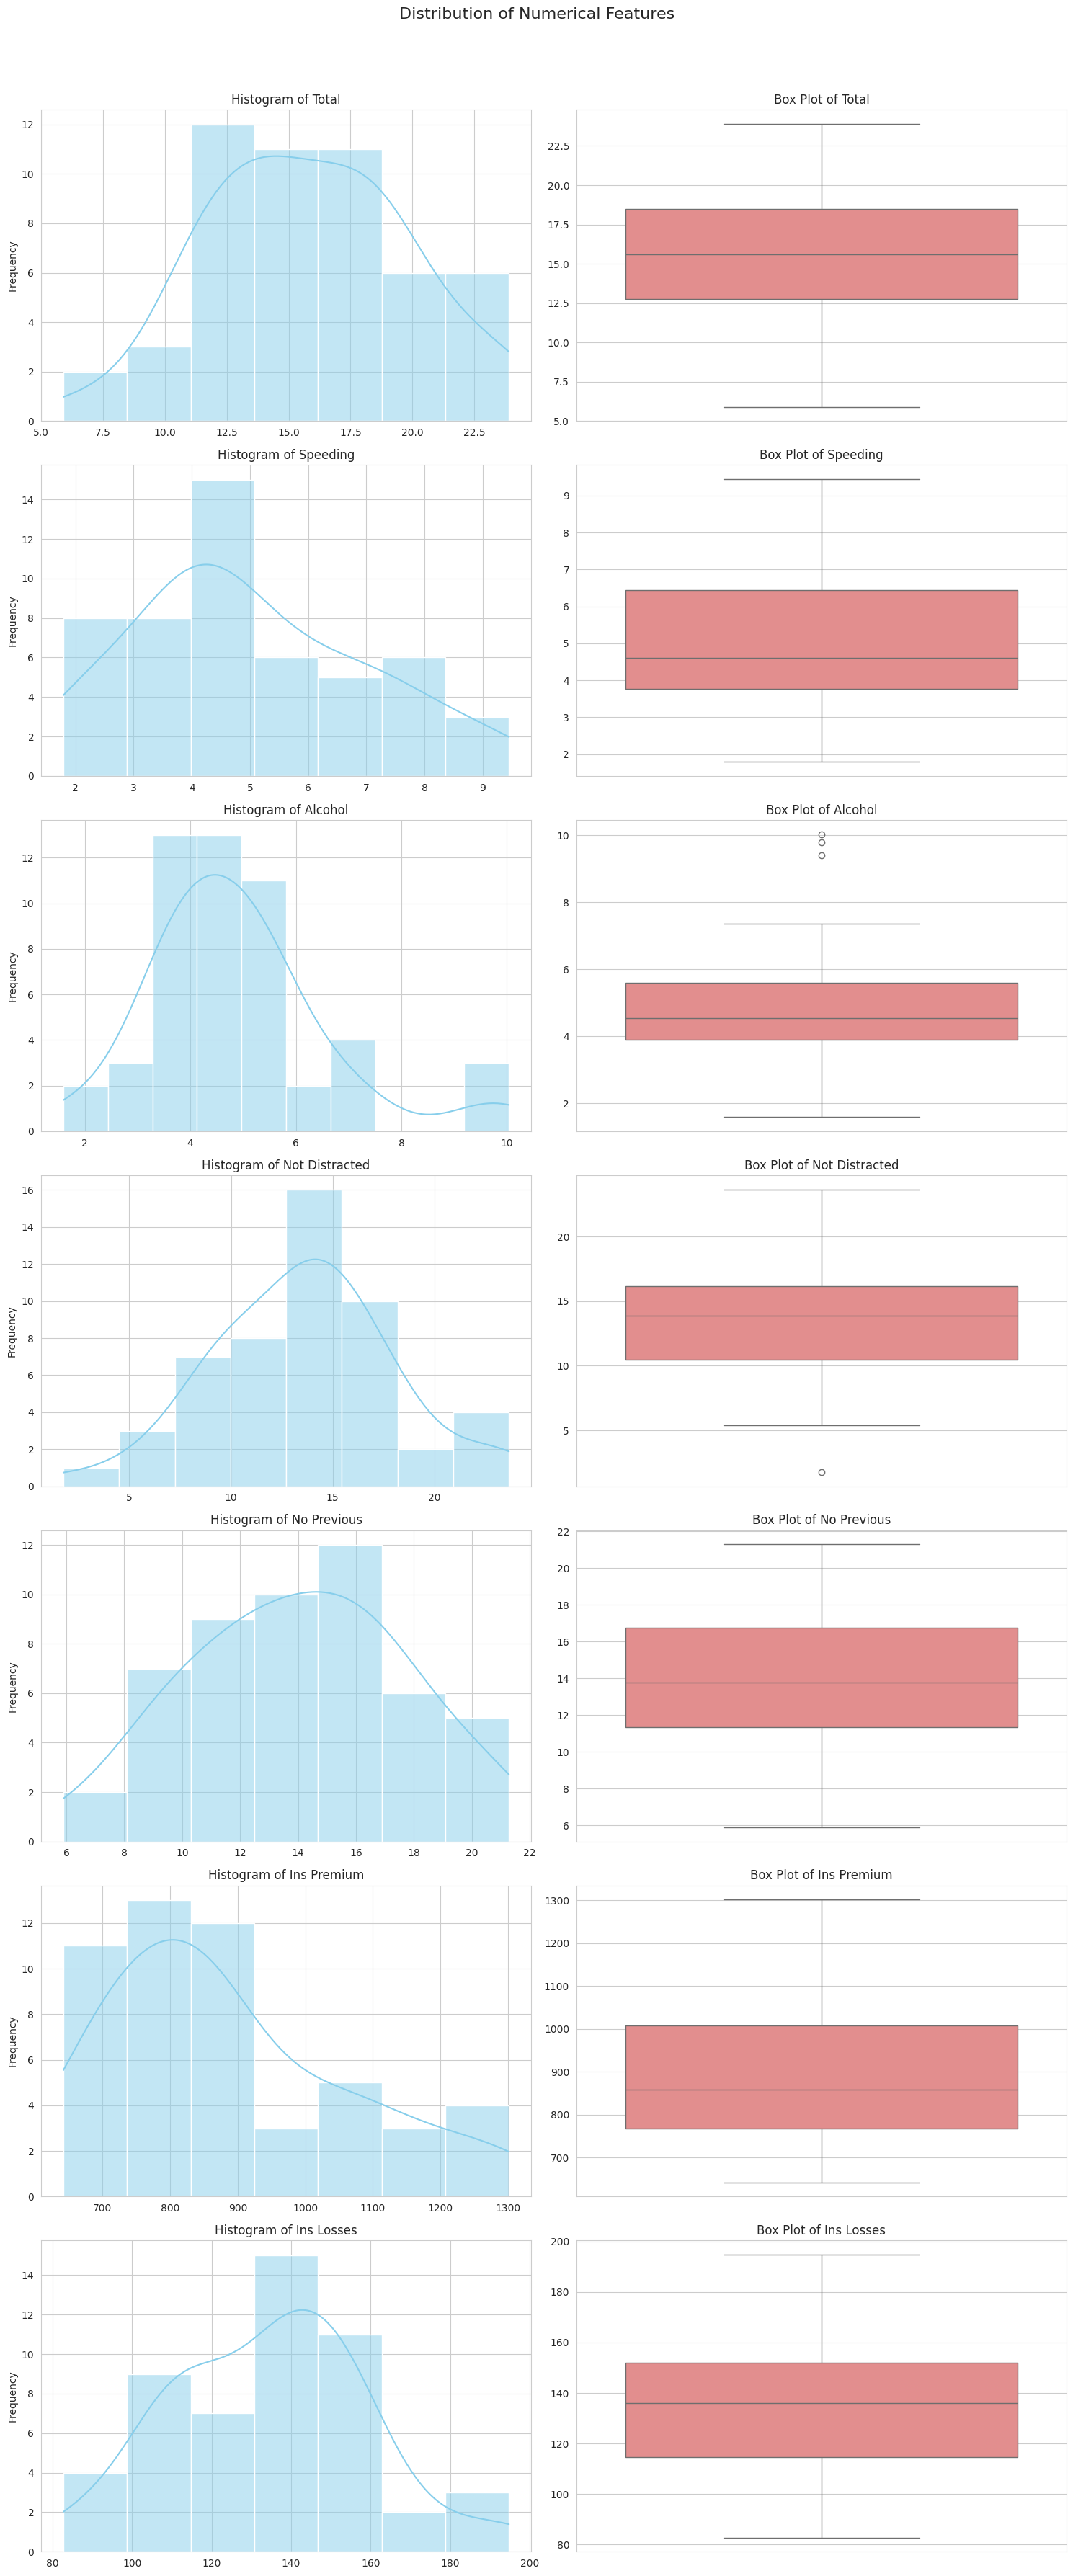

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Get numerical columns (excluding 'abbrev' which is categorical)
numerical_cols = car_crashes.select_dtypes(include=['float64']).columns

# Create subplots for histograms and box plots
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(15, 5 * len(numerical_cols)))
fig.suptitle('Distribution of Numerical Features', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    # Histogram
    sns.histplot(car_crashes[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {col.replace("_", " ").title()}')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frequency')

    # Box Plot
    sns.boxplot(y=car_crashes[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Box Plot of {col.replace("_", " ").title()}')
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()

### **Interpretation of Distribution Analysis:**

*   **Histograms**: Show the frequency distribution of each variable. We can observe if distributions are normal, skewed (left or right), or bimodal. For example, `total` crashes seem somewhat normally distributed, while `alcohol` and `speeding` might be right-skewed, indicating more states with lower values and fewer with very high values.
*   **Box Plots**: Provide a five-number summary (minimum, first quartile (Q1), median, third quartile (Q3), and maximum) and highlight potential outliers (points beyond the whiskers). Outliers might represent states with unusually high or low crash-related figures or insurance values.

### **2.2. Relationships Between Variables (Scatter Plots & Correlation Matrix)**

Let's investigate how different variables relate to each other. We'll start with scatter plots to visually identify relationships, especially focusing on `total` crashes against other relevant factors like `speeding` and `alcohol`.

Then, we'll calculate and visualize the correlation matrix to quantify the strength and direction of linear relationships between all numerical pairs of variables.

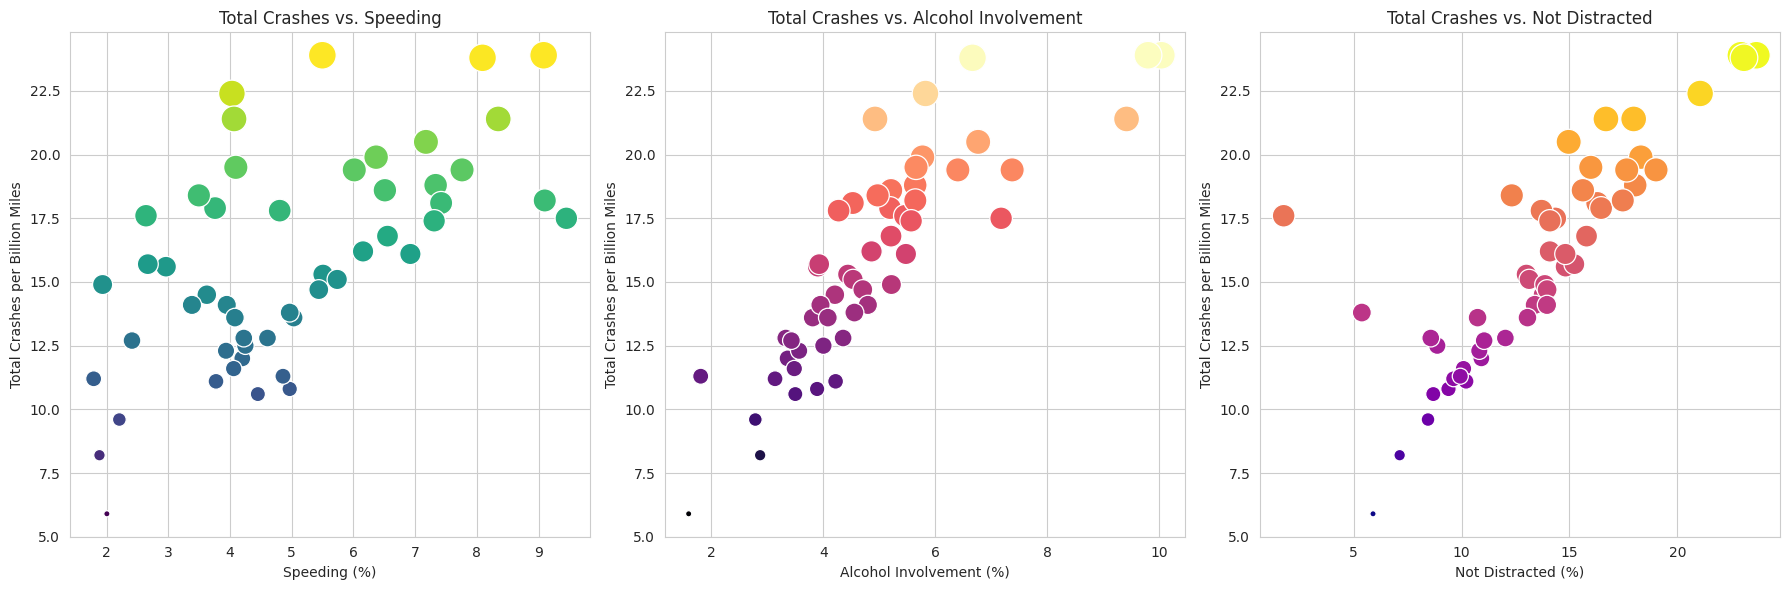

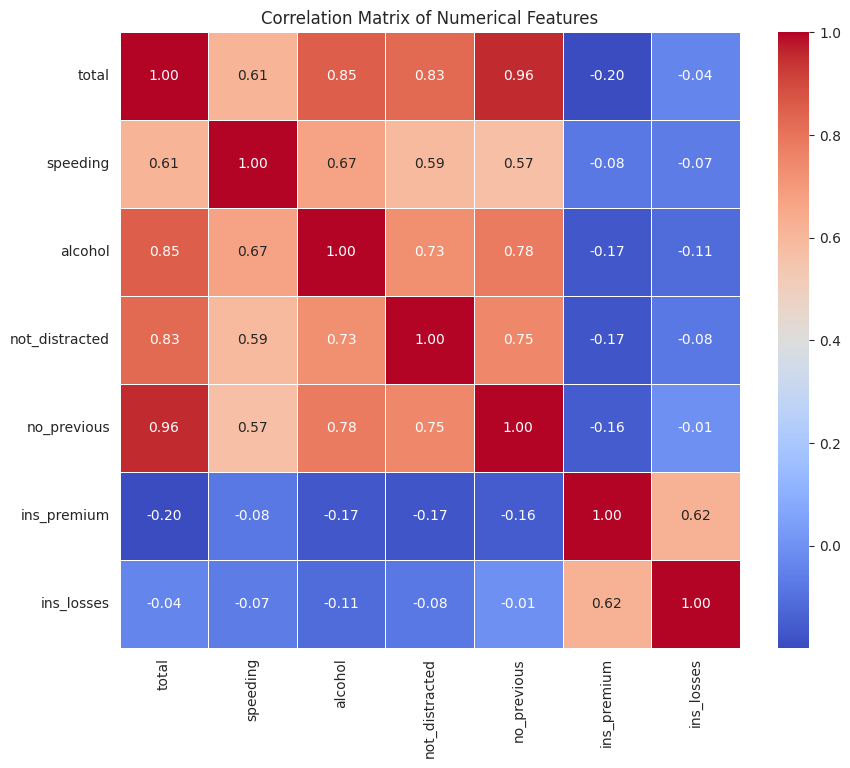

In [8]:
# Scatter plots for key relationships
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='speeding', y='total', data=car_crashes, hue='total', size='total', sizes=(20, 400), palette='viridis', legend=False)
plt.title('Total Crashes vs. Speeding')
plt.xlabel('Speeding (%)')
plt.ylabel('Total Crashes per Billion Miles')

plt.subplot(1, 3, 2)
sns.scatterplot(x='alcohol', y='total', data=car_crashes, hue='total', size='total', sizes=(20, 400), palette='magma', legend=False)
plt.title('Total Crashes vs. Alcohol Involvement')
plt.xlabel('Alcohol Involvement (%)')
plt.ylabel('Total Crashes per Billion Miles')

plt.subplot(1, 3, 3)
sns.scatterplot(x='not_distracted', y='total', data=car_crashes, hue='total', size='total', sizes=(20, 400), palette='plasma', legend=False)
plt.title('Total Crashes vs. Not Distracted')
plt.xlabel('Not Distracted (%)')
plt.ylabel('Total Crashes per Billion Miles')

plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = car_crashes[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### **Interpretation of Relationship Analysis:**

*   **Scatter Plots**: Visually demonstrate potential relationships. We can observe if there's a positive, negative, or no clear relationship between pairs of variables. For instance, it's likely we'll see positive correlations between `total` crashes and factors like `speeding` and `alcohol`.
*   **Correlation Matrix**: Provides a quantitative measure of linear correlation:
    *   Values close to `1` indicate a strong positive linear relationship.
    *   Values close to `-1` indicate a strong negative linear relationship.
    *   Values close to `0` indicate a weak or no linear relationship.
    *   This helps confirm visual observations from scatter plots and identify highly correlated variables, which can be important for feature selection in modeling.

## **3. Diagnostic Analysis**

Diagnostic analysis focuses on understanding the root causes of observed phenomena, especially anomalies or significant patterns identified during EDA. For the `car_crashes` dataset, this involves identifying states that stand out in terms of crash rates or insurance metrics and delving deeper into their specific characteristics.

### **3.1. Identifying Outliers**

Based on the box plots from EDA, we saw potential outliers. Let's programmatically identify these states using the Interquartile Range (IQR) method for key numerical features. The IQR method defines outliers as data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

In [9]:
# Function to identify outliers using the IQR method
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("\n--- States with Outliers ---\n")

# Get numerical columns again, excluding 'abbrev' for outlier detection
numerical_cols_for_outliers = car_crashes.select_dtypes(include=['float64']).columns

# Identify and display outliers for each numerical column
all_outliers = pd.DataFrame()
for col in numerical_cols_for_outliers:
    outliers = find_outliers_iqr(car_crashes, col)
    if not outliers.empty:
        print(f"Outliers in '{col.replace('_', ' ').title()}':")
        display(outliers[['abbrev', col]])
        outliers['outlier_feature'] = col
        all_outliers = pd.concat([all_outliers, outliers])

# Display unique states that are outliers in at least one feature
if not all_outliers.empty:
    unique_outlier_states = all_outliers['abbrev'].unique()
    print(f"\nUnique states identified as outliers in one or more features: {', '.join(unique_outlier_states)}")
else:
    print("No significant outliers found using the IQR method across the numerical features.")


--- States with Outliers ---

Outliers in 'Alcohol':


,abbrev,alcohol
26,MT,9.416
34,ND,10.038
40,SC,9.799


Outliers in 'Not Distracted':


/tmp/ipykernel_1007/1804340851.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['outlier_feature'] = col


,abbrev,not_distracted
24,MS,1.76



Unique states identified as outliers in one or more features: MT, ND, SC, MS


/tmp/ipykernel_1007/1804340851.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['outlier_feature'] = col


### **3.2. Investigating Specific Outliers or High/Low Performers**

Let's take a closer look at some of the states that consistently appear as outliers or are at the extreme ends of the distributions. For example, states with very high 'total' crashes or 'alcohol' involvement. This involves looking at all available features for these particular states to understand their overall profile.

We'll pick a few prominent ones based on our previous observations and the identified outliers.

In [10]:
# Example: Investigate the state with the highest 'total' crashes
highest_total_crash_state = car_crashes.loc[car_crashes['total'].idxmax()]
print("\n--- State with Highest Total Crashes ---")
display(highest_total_crash_state.to_frame().T)

# Example: Investigate the state with the highest 'alcohol' involvement
highest_alcohol_state = car_crashes.loc[car_crashes['alcohol'].idxmax()]
print("\n--- State with Highest Alcohol Involvement in Crashes ---")
display(highest_alcohol_state.to_frame().T)

# Example: Investigate a state with low 'total' crashes (if any identified as low outlier or just min value)
lowest_total_crash_state = car_crashes.loc[car_crashes['total'].idxmin()]
print("\n--- State with Lowest Total Crashes ---")
display(lowest_total_crash_state.to_frame().T)

# If specific outliers were found, investigate one in detail (e.g., if 'abbrev' 'NY' was an outlier)
# For demonstration, let's pick one of the unique outlier states if available
if not all_outliers.empty:
    example_outlier_abbrev = unique_outlier_states[0] # Pick the first identified outlier state
    print(f"\n--- Detailed Profile of an Example Outlier State ({example_outlier_abbrev}) ---")
    display(car_crashes[car_crashes['abbrev'] == example_outlier_abbrev])


--- State with Highest Total Crashes ---


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
34,23.9,5.497,10.038,23.661,20.554,688.75,109.72,ND



--- State with Highest Alcohol Involvement in Crashes ---


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
34,23.9,5.497,10.038,23.661,20.554,688.75,109.72,ND



--- State with Lowest Total Crashes ---


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
8,5.9,2.006,1.593,5.9,5.9,1273.89,136.05,DC



--- Detailed Profile of an Example Outlier State (MT) ---


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
26,21.4,8.346,9.416,17.976,18.19,816.21,85.15,MT


### **Interpretation of Diagnostic Analysis:**

*   **Outlier Identification**: By using methods like the IQR, we can systematically detect states that fall outside the typical range for various crash-related metrics. This highlights specific states that warrant further investigation.
*   **Detailed Investigation**: By examining the full profile of these outlier states (e.g., states with highest total crashes or alcohol involvement), we can look for clues or unique combinations of factors. For instance, a state with very high `ins_premium` and `ins_losses` might be correlated with higher crash rates, or a state with low `not_distracted` percentage might indicate higher distraction-related incidents. This step helps in forming hypotheses about *why* these states are different, which can then be tested in Inferential Analysis.

## **4. Inferential Analysis**

Inferential analysis aims to draw conclusions and make predictions about a population based on a sample of data. It involves using statistical tests to examine relationships between variables, compare groups, and test hypotheses. In this section, we will:

*   Test the statistical significance of observed correlations.
*   Compare means between different groups of states to see if observed differences are statistically significant.

### **4.1. Hypothesis Testing: Correlation Significance**

**Hypothesis:** There is a significant positive linear relationship between `total` crashes and both `speeding` and `alcohol` involvement.

We will use Pearson correlation coefficients and their associated p-values to determine the statistical significance of these relationships.

In [11]:
from scipy.stats import pearsonr

# Calculate Pearson correlation and p-value for 'total' vs 'speeding'
corr_speeding, p_value_speeding = pearsonr(car_crashes['total'], car_crashes['speeding'])
print(f"Pearson Correlation between Total Crashes and Speeding: {corr_speeding:.2f} (p-value: {p_value_speeding:.3f})")

# Calculate Pearson correlation and p-value for 'total' vs 'alcohol'
corr_alcohol, p_value_alcohol = pearsonr(car_crashes['total'], car_crashes['alcohol'])
print(f"Pearson Correlation between Total Crashes and Alcohol Involvement: {corr_alcohol:.2f} (p-value: {p_value_alcohol:.3f})")

# Set significance level
alpha = 0.05
print(f"\nSignificance Level (alpha): {alpha}")

if p_value_speeding < alpha:
    print("Conclusion: The correlation between Total Crashes and Speeding is statistically significant.")
else:
    print("Conclusion: The correlation between Total Crashes and Speeding is NOT statistically significant.")

if p_value_alcohol < alpha:
    print("Conclusion: The correlation between Total Crashes and Alcohol Involvement is statistically significant.")
else:
    print("Conclusion: The correlation between Total Crashes and Alcohol Involvement is NOT statistically significant.")

Pearson Correlation between Total Crashes and Speeding: 0.61 (p-value: 0.000)
Pearson Correlation between Total Crashes and Alcohol Involvement: 0.85 (p-value: 0.000)

Significance Level (alpha): 0.05
Conclusion: The correlation between Total Crashes and Speeding is statistically significant.
Conclusion: The correlation between Total Crashes and Alcohol Involvement is statistically significant.


### **Interpretation of Correlation Significance:**

*   A p-value less than our chosen significance level (commonly 0.05) indicates that the observed correlation is unlikely to have occurred by random chance, suggesting a statistically significant relationship. Based on the output, we can conclude if the strong positive correlations seen in EDA for `speeding` and `alcohol` with `total` crashes are statistically meaningful.

### **4.2. Hypothesis Testing: Group Comparison (T-test)**

**Hypothesis:** States with high alcohol involvement in crashes have a significantly higher average `total` crash rate than states with low alcohol involvement.

We will divide the states into two groups (high and low alcohol involvement, based on the median) and then perform an independent samples t-test to compare their average `total` crash rates.

In [12]:
from scipy.stats import ttest_ind

# Divide states into high and low alcohol involvement groups based on the median
median_alcohol = car_crashes['alcohol'].median()

high_alcohol_states = car_crashes[car_crashes['alcohol'] >= median_alcohol]
low_alcohol_states = car_crashes[car_crashes['alcohol'] < median_alcohol]

# Perform independent samples t-test on 'total' crashes
t_stat, p_value_t_test = ttest_ind(high_alcohol_states['total'], low_alcohol_states['total'])

print(f"Average Total Crashes for High Alcohol States: {high_alcohol_states['total'].mean():.2f}")
print(f"Average Total Crashes for Low Alcohol States: {low_alcohol_states['total'].mean():.2f}")
print(f"\nT-statistic: {t_stat:.2f} (p-value: {p_value_t_test:.3f})")

if p_value_t_test < alpha:
    print("Conclusion: There is a statistically significant difference in total crash rates between states with high and low alcohol involvement.")
else:
    print("Conclusion: There is NO statistically significant difference in total crash rates between states with high and low alcohol involvement.")

Average Total Crashes for High Alcohol States: 18.71
Average Total Crashes for Low Alcohol States: 12.75

T-statistic: 7.48 (p-value: 0.000)
Conclusion: There is a statistically significant difference in total crash rates between states with high and low alcohol involvement.


### **Interpretation of Group Comparison:**

*   The t-test helps us determine if the observed difference in the mean `total` crash rates between the two groups (high vs. low alcohol involvement) is likely due to a real underlying difference in the population or just random chance. A small p-value (e.g., < 0.05) indicates a significant difference, supporting our hypothesis.

## **5. Predictive Analysis**

Predictive analysis involves building models to forecast future outcomes or estimate unknown values. Here, we'll demonstrate a basic predictive model using linear regression to predict the `total` number of crashes based on other influential factors identified during EDA and Inferential Analysis.

### **5.1. Simple Linear Regression Model**

We'll use `speeding` and `alcohol` as features to predict `total` crashes, given their strong correlations observed earlier. We'll split the data into training and testing sets to evaluate our model's performance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = car_crashes[['speeding', 'alcohol', 'ins_premium']]
y = car_crashes['total']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Linear Regression Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {model.intercept_:.2f}")


--- Linear Regression Model Performance ---
Mean Squared Error (MSE): 8.60
R-squared (R2) Score: 0.52

Model Coefficients:
  speeding: 0.43
  alcohol: 1.72
  ins_premium: -0.00
  Intercept: 6.03


### **Interpretation of Predictive Analysis:**

*   **Mean Squared Error (MSE)**: Measures the average squared difference between the estimated values and the actual value. Lower MSE indicates a better fit.
*   **R-squared (R2) Score**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score closer to 1 indicates that a large proportion of the variance is explained by the model.
*   **Model Coefficients**: Indicate the strength and direction of the relationship between each feature and the target variable. For example, a positive coefficient for `speeding` means that as speeding involvement increases, the total crashes are predicted to increase, holding other factors constant.

## **6. Prescriptive Analysis**

Prescriptive analysis aims to provide actionable recommendations and strategies to influence future outcomes. It answers the question: "What should we do?" Based on the insights from our Descriptive, Exploratory, Diagnostic, Inferential, and Predictive analyses, we can propose data-driven suggestions to potentially reduce car crashes.

### **6.1. Recommendations Based on Analysis**

Let's synthesize our findings to generate some practical recommendations:

#### **Key Findings to Base Prescriptions On:**

1.  **Strong Positive Correlation with Speeding and Alcohol:** Both `speeding` and `alcohol` involvement showed strong positive correlations with `total` crashes and were statistically significant predictors.
2.  **Outlier States:** We identified states that are outliers in terms of high total crashes, alcohol involvement, or speeding.
3.  **Insurance Metrics:** `ins_premium` and `ins_losses` also showed positive correlations, suggesting that states with higher crash risks might have higher insurance costs and losses.

#### **Prescriptive Actions:**

Based on these findings, here are some actionable recommendations:

*   **Targeted Enforcement and Awareness Campaigns:**
    *   **Recommendation:** States, especially those identified as outliers with high `speeding` and `alcohol` involvement, should implement more stringent enforcement measures for speed limits and impaired driving laws.
    *   **Action:** Increase police presence in high-risk areas, conduct frequent sobriety checkpoints, and utilize speed cameras.
    *   **Goal:** Directly reduce the primary contributing factors to fatal crashes.

*   **Public Education Initiatives:**
    *   **Recommendation:** Launch public awareness campaigns emphasizing the dangers of speeding and driving under the influence of alcohol.
    *   **Action:** Use multi-channel campaigns (TV, radio, social media, roadside billboards) to educate the public on the consequences of these behaviors.
    *   **Goal:** Influence driver behavior and promote safer driving habits across all states, not just outliers.

*   **Policy Review and Legislative Changes:**
    *   **Recommendation:** Policymakers should review existing traffic laws and consider stricter penalties for speeding and DUI offenses, particularly in states with persistently high rates.
    *   **Action:** Evaluate the effectiveness of current laws, potentially increasing fines, license suspension periods, or mandatory education programs.
    *   **Goal:** Create a stronger deterrent effect and encourage compliance.

*   **Driver Education Enhancement:**
    *   **Recommendation:** Integrate more comprehensive modules on the risks of speeding and impaired driving into driver's education programs.
    *   **Action:** Focus on defensive driving techniques and decision-making under pressure, especially for new drivers.
    *   **Goal:** Build a foundation of safe driving practices from an early age.

*   **Data-Driven Resource Allocation:**
    *   **Recommendation:** States should use crash data to identify specific locations (e.g., particular highways, intersections) that are prone to crashes related to speeding or alcohol.
    *   **Action:** Allocate resources for infrastructure improvements (e.g., better lighting, road design, signage) and targeted enforcement in these identified hotspots.
    *   **Goal:** Optimize the use of resources for maximum impact on crash reduction.


Prescriptive analysis turns raw data and statistical insights into practical, implementable strategies, guiding decision-makers toward proactive measures to improve safety outcomes.